# 자기 일관성 (Self-Consistency)

자기 일관성은 사고 연쇄 프롬프팅(Chain-of-Thought)을 확장한 기법으로, 하나의 추론 경로 대신 여러 추론 경로를 생성한 후 다수결이나 확신도 등을 기준으로 가장 일관된 답변을 선택하는 방식입니다. 이 방법은 특히 복잡한 추론 문제에서 모델의 정확도를 향상시킬 수 있습니다.

이 노트북에서는 자기 일관성 기법의 기본 개념을 배우고 다양한 작업에 적용해보겠습니다.

In [1]:
# 필요한 라이브러리 및 모듈 임포트
import os
import sys
import random
import collections
from dotenv import load_dotenv

# utils 디렉토리의 helpers.py 모듈을 임포트하기 위한 경로 설정
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from utils.helpers import get_completion

# .env 파일 로드
load_dotenv()

True

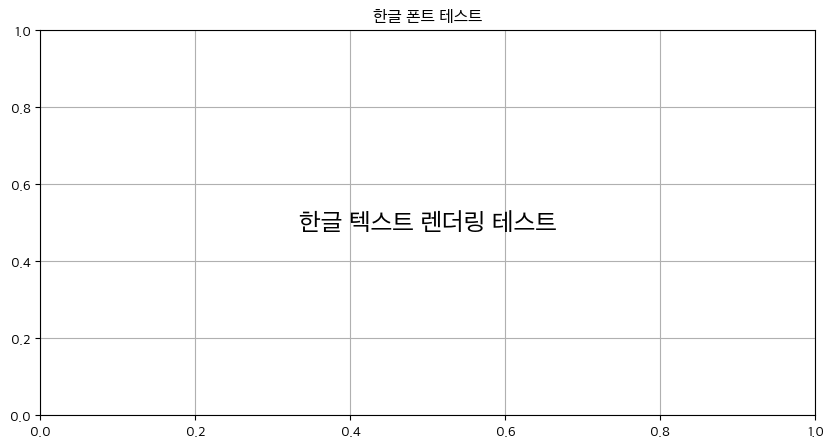

Apple SD Gothic Neo 폰트 설정이 완료되었습니다.


In [2]:
# macOS 기본 한글 폰트 설정
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# macOS 기본 한글 폰트 설정
plt.rc('font', family='Apple SD Gothic Neo')  # macOS 기본 고품질 한글 폰트
plt.rc('axes', unicode_minus=False)  # 마이너스 부호 깨짐 해결

# 폰트 테스트 코드
def test_korean_font():
    plt.figure(figsize=(10, 5))
    plt.title('한글 폰트 테스트')
    plt.text(0.5, 0.5, '한글 텍스트 렌더링 테스트', 
             ha='center', va='center', fontsize=18)
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(True)
    plt.show()
    
    print("Apple SD Gothic Neo 폰트 설정이 완료되었습니다.")

# 테스트 실행
test_korean_font()

## 1. 자기 일관성의 기본 개념

자기 일관성 기법은 다음과 같은 단계로 이루어집니다:

1. 사고 연쇄 프롬프팅을 통해 같은 문제에 대해 여러 번 다른 추론 경로를 생성
2. 각 추론 경로에서 도출된 최종 답변을 수집
3. 가장 많이 등장한 답변(다수결) 또는 확신도가 높은 답변을 최종 답변으로 선택

이 방법의 핵심은 다양한 추론 경로를 통해 같은 문제를 여러 방향에서 접근함으로써 개별 추론 과정의 오류를 줄이는 것입니다.

## 2. 자기 일관성 구현 함수

먼저 자기 일관성을 구현하기 위한 함수를 만들어보겠습니다. 이 함수는 같은 프롬프트로 여러 번 응답을 생성하고, 가장 많이 나타난 답변을 선택합니다.

In [3]:
def self_consistency(prompt, n_samples=3, temperature=0.7, extract_answer=None):
    """
    자기 일관성 방법을 구현한 함수
    
    Args:
        prompt (str): 모델에게 보낼 프롬프트
        n_samples (int): 생성할 추론 경로의 수
        temperature (float): 응답의 다양성을 조절하는 파라미터 (0~1)
        extract_answer (callable, optional): 응답에서 최종 답변만 추출하는 함수
        
    Returns:
        dict: 다수결 결과, 모든 추론 결과, 빈도수 등의 정보
    """
    # 여러 추론 경로 생성
    responses = []
    for i in range(n_samples):
        response = get_completion(prompt, temperature=temperature)
        responses.append(response)
        print(f"샘플 {i+1}의 응답:\n{response}\n\n")
    
    # 최종 답변 추출
    if extract_answer is not None:
        answers = [extract_answer(response) for response in responses]
    else:
        answers = responses
    
    # 다수결로 최종 답변 선택
    answer_counts = collections.Counter(answers)
    majority_answer = answer_counts.most_common(1)[0][0]
    
    return {
        "majority_answer": majority_answer,
        "all_answers": answers,
        "answer_counts": answer_counts,
        "all_responses": responses
    }

## 3. 간단한 수학 문제에 자기 일관성 적용

먼저 간단한 수학 문제에 자기 일관성을 적용해보겠습니다.

In [4]:
# 간단한 수학 문제에 자기 일관성 적용
math_problem = """
철수는 사과를 몇 개 가지고 있었습니다. 그는 영희에게 사과의 절반을 주었고, 
그 다음 민수에게 남은 사과의 1/3을 주었습니다. 그 후 철수에게 남은 사과는 8개입니다. 
처음에 철수는 사과를 몇 개 가지고 있었을까요?
"""

prompt = f"""
다음 수학 문제를 단계별로 해결해주세요. 자세한 풀이 과정을 보여주고 최종 답을 'x = 정답'과 같은 형식으로 표시해주세요.

{math_problem}
"""

# 최종 답변을 추출하는 함수
def extract_math_answer(response):
    lines = response.strip().split('\n')
    for line in reversed(lines):  # 마지막 줄부터 확인
        if '=' in line:
            parts = line.split('=')
            if len(parts) > 1:
                answer = parts[1].strip()
                # 숫자만 추출
                answer = ''.join(c for c in answer if c.isdigit())
                return answer
    return None

# 자기 일관성 적용 (샘플 수를 3으로 줄여 실행 시간 단축)
result = self_consistency(prompt, n_samples=3, temperature=0.8, extract_answer=extract_math_answer)

print("\n===== 자기 일관성 결과 =====")
print(f"다수결 답변: {result['majority_answer']}")
print(f"답변 빈도수: {result['answer_counts']}")

샘플 1의 응답:
문제를 단계별로 해결해 보겠습니다.

1. **문제 이해하기:**
   - 철수는 처음에 사과를 \( x \)개 가지고 있었습니다.
   - 철수는 먼저 영희에게 사과의 절반을 주었습니다. 이때 남은 사과는 \( \frac{x}{2} \)개입니다.
   - 그런 다음 철수는 민수에게 남은 사과의 1/3을 주었습니다. 민수에게 준 사과의 개수는 \(\frac{1}{3} \times \frac{x}{2} = \frac{x}{6}\)개입니다.
   - 따라서 민수에게 사과를 준 후 철수에게 남은 사과는 \(\frac{x}{2} - \frac{x}{6}\)개입니다.
   - 철수에게 남은 사과는 8개라고 했으므로, 식을 세울 수 있습니다:

\[
\frac{x}{2} - \frac{x}{6} = 8
\]

2. **식 풀기:**

   - 공통 분모를 찾아 정리합니다. \( \frac{x}{2} \)와 \(\frac{x}{6}\)의 공통 분모는 6입니다.

\[
\frac{3x}{6} - \frac{x}{6} = 8
\]

   - 분수들을 계산합니다.

\[
\frac{3x - x}{6} = 8
\]

   - 분자에서 계산을 수행합니다.

\[
\frac{2x}{6} = 8
\]

   - 양변에 6을 곱하여 분수를 제거합니다.

\[
2x = 48
\]

   - 양변을 2로 나누어 \( x \)를 구합니다.

\[
x = 24
\]

3. **결론:**

   - 처음에 철수는 사과를 24개 가지고 있었습니다.

따라서 최종 답은:

\[ x = 24 \]


샘플 2의 응답:
이 문제는 역추적을 통해 해결할 수 있습니다. 철수가 처음에 가지고 있던 사과의 수를 구하기 위해 남은 사과의 수에서 출발하여 문제의 조건을 역순으로 따라가 보겠습니다.

1. 철수에게 남아 있는 사과의 수는 8개입니다.

2. 철수가 마지막으로 민수에게 남은 사과의 1/3을 주었으므로, 남은 사과의 2/3이 8개입니다. 따라서 남은 사과의 전체 수를 \( y \)라고

## 4. 복잡한 추론 문제에 자기 일관성 적용

이번에는 좀 더 복잡한 추론이 필요한 논리 퍼즐에 자기 일관성을 적용해보겠습니다.

In [15]:
# 복잡한 논리 퍼즐에 자기 일관성 적용
logic_puzzle = """
다음은 세 사람(갑, 을, 병)의 진술입니다. 이 중 정직한 사람은 항상 진실만을 말하고, 
거짓말쟁이는 항상 거짓말만 합니다. 세 사람 중 누가 정직하고 누가 거짓말쟁이인지 판단하세요.

갑: "나는 정직하다. 을은 거짓말쟁이다."
을: "만약 갑이 정직하다면, 병도 정직하다."
병: "나는 정직하지만, 갑은 거짓말쟁이다."
"""

prompt = f"""
<system>
다음 논리 퍼즐을 단계별로 해결해주세요. 가능한 모든 경우의 수를 검토하고, 
각 진술이 일관성이 있는지 차근차근 분석해보세요.

마지막에는 각 사람이 정직한지 거짓말쟁이인지 명확하게 결론을 내려주세요.

- 답변 형식은 <answer_format>에 제시된 형태와 같은 형태로 구성해주세요.
- [] 태그 안에 있는 것은 or를 표현한 것으로 기호 없이 표현해주세요.
- 답변시 xml태그는 무시해주세요.
</system>

<answer_format>
갑: [정직/거짓말쟁이], 을: [정직/거짓말쟁이], 병: [정직/거짓말쟁이]
</answer_format>

<user_input>
{logic_puzzle}
</user_input>
"""

# 최종 답변을 추출하는 함수
def extract_logic_answer(response):
    lines = response.strip().split('\n')
    for line in lines:
        if "갑:" in line and "을:" in line and "병:" in line:
            return line.strip()
    return None

# 자기 일관성 적용
result = self_consistency(prompt, n_samples=5, temperature=0.5, extract_answer=extract_logic_answer)

print("\n===== 자기 일관성 결과 =====")
print(f"다수결 답변: {result['majority_answer']}")
print(f"답변 빈도수: {result['answer_counts']}")

샘플 1의 응답:
문제를 해결하기 위해 각 사람의 진술을 분석하고 가능한 모든 경우의 수를 검토하겠습니다.

1. **갑의 진술**: "나는 정직하다. 을은 거짓말쟁이다."
   - 갑이 정직하다면, 갑의 모든 진술은 참이어야 합니다. 따라서 갑이 정직하다는 말과 을이 거짓말쟁이라는 말이 모두 참이어야 합니다.
   - 갑이 거짓말쟁이라면, 갑의 모든 진술은 거짓이어야 합니다. 따라서 갑이 정직하다는 말과 을이 거짓말쟁이라는 말이 모두 거짓이어야 합니다.

2. **을의 진술**: "만약 갑이 정직하다면, 병도 정직하다."
   - 을이 정직하다면, 을의 진술은 참이어야 합니다. 즉, 갑이 정직하다면 병도 정직해야 합니다.
   - 을이 거짓말쟁이라면, 을의 진술은 거짓이어야 합니다. 즉, 갑이 정직하지만 병은 정직하지 않아야 합니다.

3. **병의 진술**: "나는 정직하지만, 갑은 거짓말쟁이다."
   - 병이 정직하다면, 병의 모든 진술은 참이어야 합니다. 따라서 병이 정직하다는 말과 갑이 거짓말쟁이라는 말이 모두 참이어야 합니다.
   - 병이 거짓말쟁이라면, 병의 모든 진술은 거짓이어야 합니다. 따라서 병이 정직하다는 말과 갑이 거짓말쟁이라는 말이 모두 거짓이어야 합니다.

이제 가능한 경우의 수를 검토하겠습니다:

**경우의 수 1: 갑이 정직하다**
- 갑이 정직하므로, 갑의 진술에 따라 을은 거짓말쟁이입니다.
- 을이 거짓말쟁이라면, 을의 진술은 거짓이어야 합니다. 즉, 갑이 정직하지만 병은 정직하지 않아야 합니다.
- 갑이 정직하므로, 병은 정직하지 않아야 합니다.

결론: 갑은 정직, 을은 거짓말쟁이, 병은 거짓말쟁이입니다.

**경우의 수 2: 갑이 거짓말쟁이다**
- 갑이 거짓말쟁이라면, 갑의 진술은 거짓이어야 합니다. 따라서 갑이 정직하지 않고, 을은 정직합니다.
- 을이 정직하므로, 을의 진술은 참이어야 합니다. 즉, 갑이 정직하지 않으므로 을의 진술은 참입니다.
- 병의 진술에 따르면, 병이 정직하고 갑은 거짓말쟁이입니다. 이는 갑

## 5. 모호한 문제에 자기 일관성 적용

자기 일관성은 명확한 정답이 없는 모호한 문제에서도 유용할 수 있습니다. 이런 경우, 다양한 관점에서 문제를 바라보고 가장 일관된 접근 방식을 찾을 수 있습니다.

In [6]:
# 모호한 윤리적 딜레마에 자기 일관성 적용
ethical_dilemma = """
자율주행 자동차가 도로를 주행 중 갑자기 브레이크가 고장 났습니다. 
앞에는 두 가지 경로가 있습니다:
1. 직진하면 5명의 보행자가 다칠 것입니다.
2. 핸들을 꺾으면 1명의 보행자가 다칠 것입니다.

자율주행 자동차는 어떤 결정을 내려야 할까요? 이 상황에서 윤리적으로 올바른 선택은 무엇일까요?
"""

prompt = f"""
다음 윤리적 딜레마를 다양한 윤리 이론과 관점에서 분석해주세요. 
공리주의, 의무론, 덕 윤리, 사회 계약론 등 다양한 윤리적 프레임워크를 고려하세요.
각 관점의 장단점을 분석하고, 마지막에 가장 합리적인 결론이 무엇인지 제시해주세요.

{ethical_dilemma}

마지막에는 "결론: [선택1/선택2]"와 같은 형식으로 최종 판단을 명시해주세요.
"""

# 최종 답변을 추출하는 함수
def extract_ethical_answer(response):
    lines = response.strip().split('\n')
    for line in lines:
        if "결론:" in line:
            choice = line.split("결론:")[1].strip()
            if "1" in choice or "직진" in choice:
                return "선택1"
            elif "2" in choice or "핸들" in choice:
                return "선택2"
    return None

# 자기 일관성 적용
result = self_consistency(prompt, n_samples=3, temperature=0.8, extract_answer=extract_ethical_answer)

print("\n===== 자기 일관성 결과 =====")
print(f"다수결 답변: {result['majority_answer']}")
print(f"답변 빈도수: {result['answer_counts']}")

샘플 1의 응답:
이 딜레마를 분석하기 위해 여러 윤리 이론을 고려해보겠습니다.

1. **공리주의 (Utilitarianism)**:
   - 공리주의는 최대 다수의 최대 행복을 추구하는 철학입니다. 이 관점에서는 결과를 중시하며, 가장 많은 사람에게 이익이 되는 선택을 옳다고 봅니다.
   - 이 딜레마에서 공리주의적 분석은 1명보다는 5명의 보행자가 다치는 것을 피하는 것이 더 나은 결과로 여겨질 수 있습니다. 따라서, 핸들을 꺾어 1명의 보행자가 다치게 하는 것이 공리주의의 관점에서는 윤리적으로 더 옳다고 볼 수 있습니다.
   - 장점: 결과를 중시하여 다수의 행복을 최대화할 수 있습니다.
   - 단점: 소수의 권리가 침해될 수 있습니다.

2. **의무론 (Deontology)**:
   - 의무론은 행동의 결과보다는 행위 자체의 도덕성을 중시합니다. 칸트의 의무론에서는 인간을 수단이 아닌 목적으로 대할 것을 강조합니다.
   - 이 경우, 어떤 경로를 택하든 한 명의 생명을 수단으로 사용하여 다른 이들의 생명을 구하는 것이 문제될 수 있습니다. 따라서, 의무론적 관점에서는 행위 자체가 도덕적으로 옳은지를 판단하며, 의도적으로 1명을 다치게 하는 것을 피하려 할 수 있습니다.
   - 장점: 행위의 도덕적 원칙을 명확히 합니다.
   - 단점: 결과의 실용적 가치를 무시할 수 있습니다.

3. **덕 윤리 (Virtue Ethics)**:
   - 덕 윤리는 행위자의 성품과 덕목을 중시합니다. 즉, 덕 있는 사람이 어떤 결정을 내릴지를 고려합니다.
   - 이 상황에서 덕 윤리적 관점은 자비, 용기, 지혜 등의 덕목을 가진 자율주행 시스템이 어떤 결정을 내릴지를 고민하게 됩니다. 이는 상황에 따른 유연한 판단을 가능하게 하지만, 명확한 행동 지침을 제공하지 않을 수 있습니다.
   - 장점: 개인의 성품과 맥락을 고려합니다.
   - 단점: 구체적 행동 지침이 부족할 수 있습니다.

4. **사회 계약론 (Social Contract Theory)

## 6. 자기 일관성과 확률 분포

자기 일관성을 통해 얻은 여러 답변의 확률 분포를 시각화하면 모델의 확신도를 더 잘 이해할 수 있습니다.
본 확률 분포는 예시로 `simulated_results`에 실제 데이터를 넣으면 분포를 확인할 수 있습니다.

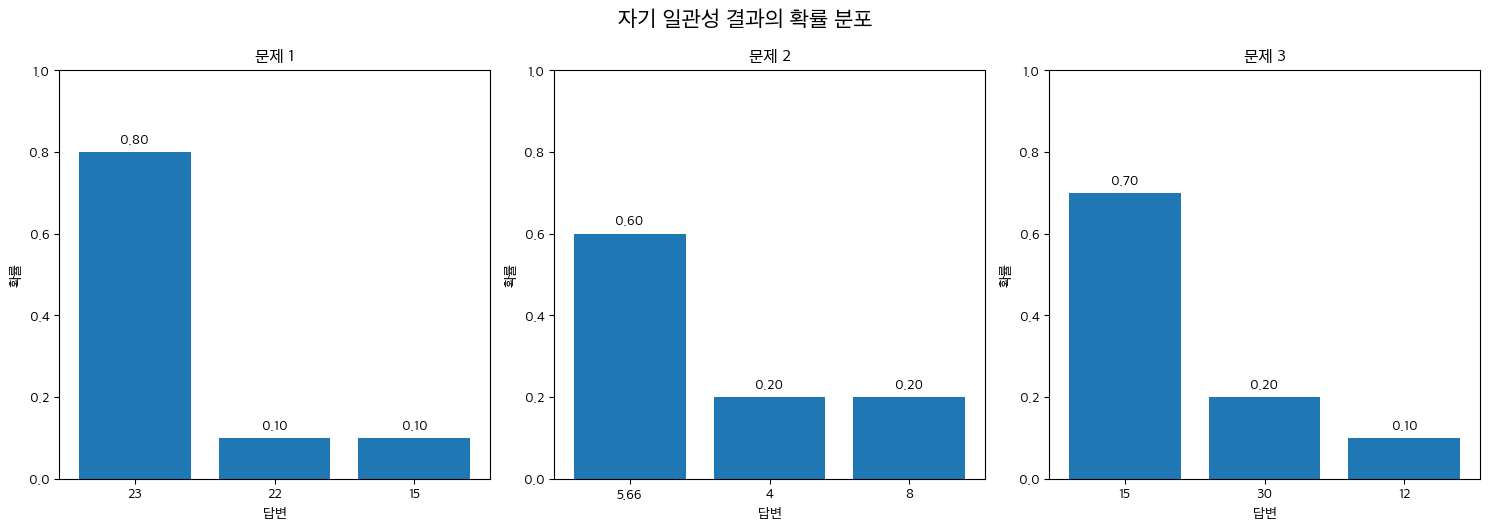

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# 여러 수학 문제에 대한 자기 일관성 결과 시각화
problems = [
    "7 + 8 × 2의 값은?",
    "정사각형의 넓이가 16cm²일 때, 대각선의 길이는?",
    "6명이 서로 악수를 할 때, 총 몇 번의 악수가 일어날까요?"
]

# 각 문제에 대한 다양한 답변과 빈도수를 시뮬레이션
# (실제로는 self_consistency 함수를 사용해 결과를 얻어야 하지만, 시간을 절약하기 위해 시뮬레이션 데이터 사용)
simulated_results = [
    {"23": 8, "22": 1, "15": 1},  # 첫 번째 문제
    {"5.66": 6, "4": 2, "8": 2},   # 두 번째 문제
    {"15": 7, "30": 2, "12": 1}    # 세 번째 문제
]

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, (problem, result) in enumerate(zip(problems, simulated_results)):
    labels = list(result.keys())
    values = list(result.values())
    
    # 확률 분포 계산
    total = sum(values)
    probabilities = [v/total for v in values]
    
    # 막대 그래프
    axes[i].bar(labels, probabilities)
    axes[i].set_ylim(0, 1)
    axes[i].set_title(f"문제 {i+1}")
    axes[i].set_xlabel("답변")
    axes[i].set_ylabel("확률")
    
    # 막대 위에 확률 표시
    for j, p in enumerate(probabilities):
        axes[i].text(j, p + 0.02, f"{p:.2f}", ha='center')

plt.tight_layout()
plt.suptitle("자기 일관성 결과의 확률 분포", y=1.05, fontsize=16)
plt.show()

## 7. 자기 일관성 vs. 일반 사고 연쇄

자기 일관성과 일반 사고 연쇄 프롬프팅의 성능을 비교해보겠습니다.

In [8]:
# 자기 일관성과 일반 사고 연쇄의 성능 비교
comparison_problem = """
배열 [3, 1, 4, 1, 5, 9, 2, 6]에서 두 번째로 큰 수와 세 번째로 작은 수의 합은?
"""

prompt = f"""
다음 수학 문제를 단계별로 해결해주세요:
{comparison_problem}

마지막에 "답: [최종 답변]"과 같은 형식으로 답을 명시해주세요.
"""

# 일반 사고 연쇄 프롬프팅
print("===== 일반 사고 연쇄 프롬프팅 =====")
cot_response = get_completion(prompt)
print(cot_response)

# 최종 답변 추출 함수
def extract_final_answer(response):
    if "답:" in response:
        answer_part = response.split("답:")[1].strip()
        return answer_part.split()[0]  # 첫 번째 단어만 반환
    return None

# 자기 일관성 적용 (3개 샘플만 사용)
print("\n\n===== 자기 일관성 프롬프팅 =====")
result = self_consistency(prompt, n_samples=3, temperature=0.7, extract_answer=extract_final_answer)

print("\n===== 결과 비교 =====")
print(f"일반 사고 연쇄 답변: {extract_final_answer(cot_response)}")
print(f"자기 일관성 다수결 답변: {result['majority_answer']}")
print(f"자기 일관성 답변 분포: {dict(result['answer_counts'])}")

===== 일반 사고 연쇄 프롬프팅 =====
주어진 배열은 [3, 1, 4, 1, 5, 9, 2, 6]입니다. 이 배열에서 두 번째로 큰 수와 세 번째로 작은 수를 찾아 합을 구하는 문제를 해결해 보겠습니다.

1. **배열 정렬하기**: 주어진 배열을 오름차순으로 정렬합니다.
   - 정렬된 배열: [1, 1, 2, 3, 4, 5, 6, 9]

2. **두 번째로 큰 수 찾기**: 정렬된 배열에서 두 번째로 큰 수는 뒤에서 두 번째 요소입니다.
   - 두 번째로 큰 수: 6

3. **세 번째로 작은 수 찾기**: 정렬된 배열에서 세 번째로 작은 수는 앞에서 세 번째 요소입니다.
   - 세 번째로 작은 수: 2

4. **합 계산하기**: 두 번째로 큰 수와 세 번째로 작은 수의 합을 계산합니다.
   - 6 + 2 = 8

따라서, 두 번째로 큰 수와 세 번째로 작은 수의 합은 8입니다.

답: 8


===== 자기 일관성 프롬프팅 =====
샘플 1의 응답:
문제를 해결하기 위해 배열에서 두 번째로 큰 수와 세 번째로 작은 수를 찾고, 이들의 합을 계산하겠습니다.

1. 배열을 오름차순으로 정렬합니다.
   - 원래 배열: [3, 1, 4, 1, 5, 9, 2, 6]
   - 정렬된 배열: [1, 1, 2, 3, 4, 5, 6, 9]

2. 두 번째로 큰 수를 찾습니다. 
   - 정렬된 배열에서 두 번째로 큰 수는 뒤에서 두 번째 요소입니다.
   - 두 번째로 큰 수: 6

3. 세 번째로 작은 수를 찾습니다.
   - 정렬된 배열에서 세 번째로 작은 수는 앞에서 세 번째 요소입니다.
   - 세 번째로 작은 수: 2

4. 두 숫자의 합을 계산합니다.
   - 6 + 2 = 8

답: 8


샘플 2의 응답:
주어진 배열에서 두 번째로 큰 수와 세 번째로 작은 수를 찾은 후, 그 합을 계산하는 과정을 단계별로 설명하겠습니다.

1. 주어진 배열을 확인합니다: \([3, 1, 4, 1, 5, 9, 2, 6]\).

2. 배열을 오름차순으로 정렬

## 8. 실습: 다양한 문제에 자기 일관성 적용하기

이제 여러분이 직접 다양한 문제에 자기 일관성을 적용해보세요. 다음은 실습해볼 수 있는 문제들입니다:

1. 복잡한 수학 문제
2. 논리 퍼즐이나 추리 게임
3. 모호한 윤리적 질문이나 의사결정 문제
4. 텍스트 분류나 감정 분석 등의 NLP 작업

각 문제에 자기 일관성을 적용하고, 답변의 분포와 다수결 결과를 분석해보세요.

In [9]:
# 여기에 여러분의 자기 일관성 실험을 작성하세요
# 예: 텍스트 감정 분석
text = """
이 영화는 전반적으로 좋은 편이었어요. 배우들의 연기는 훌륭했고 스토리도 나쁘지 않았습니다.
다만 결말이 조금 아쉽고, 중간에 지루한 부분이 있었습니다. 그래도 전체적으로는 볼만한 영화였습니다.
"""

prompt = f"""
다음 영화 리뷰의 감정을 분석해주세요. 긍정, 부정, 중립 중 하나로 분류하고, 그 이유를 설명해주세요.

리뷰: {text}

결론에는 "감정: [긍정/부정/중립]"과 같은 형식으로 답변해주세요.
"""

# 최종 답변 추출 함수
def extract_sentiment(response):
    if "감정:" in response:
        sentiment = response.split("감정:")[1].strip().lower()
        if "긍정" in sentiment:
            return "긍정"
        elif "부정" in sentiment:
            return "부정"
        elif "중립" in sentiment:
            return "중립"
    return None

# 자기 일관성 적용
result = self_consistency(prompt, n_samples=5, temperature=0.7, extract_answer=extract_sentiment)

print("\n===== 자기 일관성 결과 =====")
print(f"다수결 감정: {result['majority_answer']}")
print(f"감정 분포: {dict(result['answer_counts'])}")

샘플 1의 응답:
이 영화 리뷰는 긍정적인 요소와 부정적인 요소를 모두 포함하고 있지만, 전체적인 방향성은 긍정적입니다. 리뷰에서 "전반적으로 좋은 편이었어요", "배우들의 연기는 훌륭했고 스토리도 나쁘지 않았습니다", "전체적으로는 볼만한 영화였습니다"와 같은 긍정적인 표현이 많습니다. 물론 "결말이 조금 아쉽고, 중간에 지루한 부분이 있었습니다"라는 부정적인 부분도 언급되었지만, 전반적인 평가는 긍정적으로 보입니다. 따라서, 이 리뷰의 감정은 긍정으로 분류할 수 있습니다.

감정: 긍정


샘플 2의 응답:
이 리뷰는 영화에 대한 전반적인 인상이 좋았으며, 배우들의 연기와 스토리에 대한 긍정적인 평가가 주를 이루고 있습니다. 결말과 중간의 일부 지루한 부분에 대한 아쉬움을 표현하고 있지만, "전체적으로는 볼만한 영화"라는 결론을 통해 긍정적인 감정이 더 강하게 드러나고 있습니다. 따라서 이 리뷰의 감정은 긍정으로 분류할 수 있습니다.

감정: 긍정


샘플 3의 응답:
리뷰를 분석해보면, 전반적으로 긍정적인 요소가 강조되고 있습니다. 리뷰 작성자는 배우들의 연기와 스토리를 좋은 점으로 언급하고 있으며, "전체적으로는 볼만한 영화였습니다"라는 표현에서 영화에 대한 긍정적인 평가를 드러내고 있습니다. 물론 결말과 중간의 지루한 부분에 대한 아쉬움을 표현하고 있지만, 이는 영화 전체에 대한 긍정적인 평가를 크게 훼손하지 않고 있습니다. 따라서, 리뷰의 전반적인 감정은 긍정으로 분류할 수 있습니다.

감정: 긍정


샘플 4의 응답:
이 리뷰는 전반적으로 긍정적인 감정을 나타내고 있습니다. 리뷰어는 영화에 대해 "전반적으로 좋은 편"이라고 평가하며, 배우들의 연기를 "훌륭하다"고 칭찬했습니다. 스토리도 "나쁘지 않다"고 하여 긍정적인 측면을 강조했습니다. 비록 결말이 아쉽고 중간에 지루한 부분이 있다고 언급했지만, 이러한 부정적인 측면은 "그래도 전체적으로는 볼만한 영화"라는 긍정적인 결론으로 상쇄되었습니다. 따라서, 리뷰의 전반적인 감정은 긍정적이라 할 수 있습

## 9. 자기 일관성의 최적화 팁

효과적인 자기 일관성 적용을 위한 몇 가지 팁을 정리해보았습니다:

1. **적절한 샘플 수 선택**: 너무 적으면 다양성이 부족하고, 너무 많으면 계산 비용이 증가합니다. 보통 5~10개 정도가 적당합니다.
2. **온도(temperature) 조정**: 높은 온도(0.7~1.0)는 다양한 추론 경로를, 낮은 온도(0.2~0.5)는 더 일관된 결과를 제공합니다.
3. **답변 추출 함수 최적화**: 정확한 답변 추출을 위해 문제 유형에 맞는 추출 함수를 설계하세요.
4. **시간-정확도 트레이드오프**: 샘플 수를 늘리면 정확도가 향상되지만 시간이 더 소요됩니다.
5. **프롬프트 설계**: 명확하고 구체적인 결론 형식을 지정하면 답변 추출이 더 쉬워집니다.
6. **가중치 부여**: 모든 샘플에 동일한 가중치를 부여하는 대신, 확신도나 논리적 일관성에 기반한 가중치를 부여할 수도 있습니다.

이러한 팁을 활용하여 자기 일관성 기법의 효과를 극대화할 수 있습니다.

## 10. 요약 및 다음 단계

이 노트북에서는 자기 일관성 기법의 기본 개념과 다양한 적용 방법을 살펴보았습니다. 자기 일관성은 여러 추론 경로를 통해 같은 문제를 다양한 방향으로 접근함으로써 개별 추론 과정의 오류를 줄이는 강력한 기법입니다.

다음 노트북에서는 검색 증강 생성(Retrieval Augmented Generation, RAG) 기법에 대해 알아볼 예정입니다. RAG는 외부 지식 소스를 활용하여 모델의 응답을 향상시키는 방법입니다.

실습을 통해 배운 내용:
- 자기 일관성의 기본 원리와 구현 방법
- 다양한 문제 유형에 자기 일관성 적용하기
- 답변 추출 및 다수결 원칙 활용하기
- 자기 일관성과 일반 사고 연쇄 프롬프팅 비교하기
- 자기 일관성 최적화 팁

이러한 기법을 실제 작업에 적용하여 LLM의 성능을 최적화해보세요!